/tmp/ipykernel_524/3883338541.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab20", len(shares))
/tmp/ipykernel_524/3883338541.py:133: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


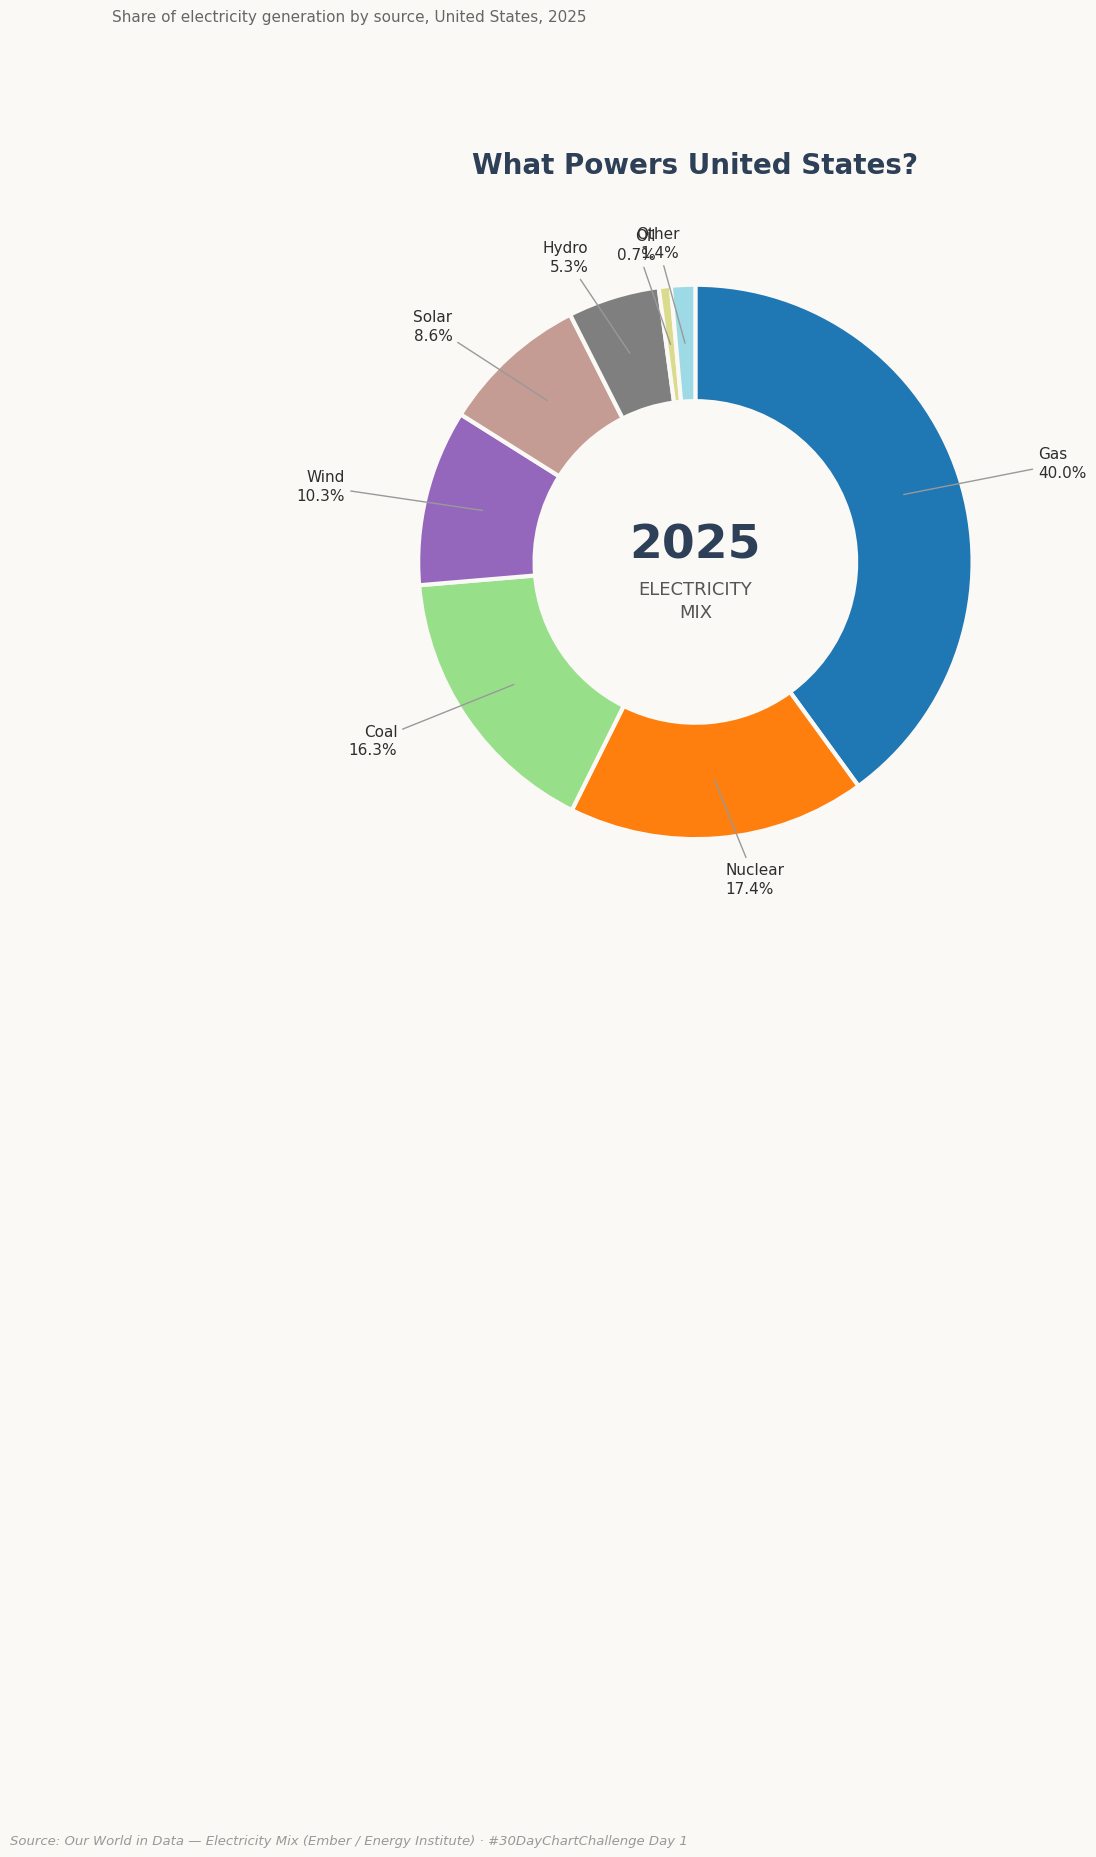

In [3]:
"""
#30DayChartChallenge — Day 1: Part-to-Whole
"What powers [Country]?" — electricity generation mix by source

Data source (loaded live, no hardcoded values):
Our World in Data — "Share of electricity production from X" data pages
https://ourworldindata.org/electricity-mix

NOTE: OWID's combined "electricity-mix.csv" export (the one that takes
frequency=/metric= query params) is currently returning HTTP 500 errors
on OWID's end — confirmed independently, not a local issue. The
single-indicator CSVs (one per source) are reliable, so this script
pulls each source's share separately with pd.read_csv and merges them.
Swap in more source slugs below if you want a finer breakdown.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. CONFIG — change these to explore a different country / year
# ---------------------------------------------------------------------------
COUNTRY = "United States"
YEAR = None  # None = automatically use the most recent year common to all sources

# Each entry: OWID grapher slug -> display label
SOURCES = {
    "share-electricity-coal": "Coal",
    "share-electricity-gas": "Gas",
    "share-electricity-oil": "Oil",
    "share-electricity-nuclear": "Nuclear",
    "share-electricity-hydro": "Hydro",
    "share-electricity-wind": "Wind",
    "share-electricity-solar": "Solar",
}

BASE_URL = "https://ourworldindata.org/grapher/{slug}.csv?v=1&csvType=full&useColumnShortNames=false"

# ---------------------------------------------------------------------------
# 2. LOAD EACH SOURCE'S CSV DIRECTLY FROM SOURCE AND MERGE
# ---------------------------------------------------------------------------
frames = []
for slug, label in SOURCES.items():
    url = BASE_URL.format(slug=slug)
    df = pd.read_csv(url, storage_options={"User-Agent": "Mozilla/5.0"})
    # The value column is whatever isn't Entity/Code/Year — rename it to the label
    value_col = [c for c in df.columns if c not in ("Entity", "Code", "Year")][0]
    df = df.rename(columns={value_col: label})[["Entity", "Year", label]]
    frames.append(df)

# Merge all sources together on Entity + Year
merged = frames[0]
for f in frames[1:]:
    merged = pd.merge(merged, f, on=["Entity", "Year"], how="outer")

# ---------------------------------------------------------------------------
# 3. FILTER TO ONE COUNTRY / YEAR
# ---------------------------------------------------------------------------
country_df = merged[merged["Entity"] == COUNTRY].copy()

if YEAR is None:
    # Use the most recent year where at least one source has non-null data
    YEAR = int(country_df.dropna(subset=list(SOURCES.values()), how="all")["Year"].max())

row = country_df[country_df["Year"] == YEAR]
if row.empty:
    raise ValueError(f"No data found for {COUNTRY} in {YEAR}. Try a different year/country.")

row = row.iloc[0]

# ---------------------------------------------------------------------------
# 4. BUILD THE PART-TO-WHOLE SERIES (drop empty/zero sources dynamically)
# ---------------------------------------------------------------------------
shares = row[list(SOURCES.values())].apply(pd.to_numeric, errors="coerce").dropna()
shares = shares[shares > 0].sort_values(ascending=False)

# Add an "Other" slice so the donut reflects the true 100% (residual = unlisted sources
# like bioenergy, other renewables, etc. not pulled above)
other = max(0.0, 100.0 - shares.sum())
if other > 0.5:
    shares["Other"] = other

clean_labels = list(shares.index)

# ---------------------------------------------------------------------------
# 5. PLOT — donut chart
# ---------------------------------------------------------------------------
palette = plt.cm.get_cmap("tab20", len(shares))
colors = [palette(i) for i in range(len(shares))]

fig, ax = plt.subplots(figsize=(9, 9), facecolor="#FAF9F6")
ax.set_facecolor("#FAF9F6")

wedges, _ = ax.pie(
    shares.values,
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.42, edgecolor="#FAF9F6", linewidth=3),
)

ax.text(0, 0.06, f"{YEAR}", fontsize=34, fontweight="bold", ha="center", va="center", color="#2E4057")
ax.text(0, -0.14, "ELECTRICITY\nMIX", fontsize=13, ha="center", va="center", color="#555555", linespacing=1.4)

for wedge, label, val in zip(wedges, clean_labels, shares.values):
    ang = np.deg2rad((wedge.theta2 + wedge.theta1) / 2)
    x, y = np.cos(ang), np.sin(ang)
    ha = "left" if x >= 0 else "right"
    ax.annotate(
        f"{label}\n{val:.1f}%",
        xy=(0.78 * x, 0.78 * y),
        xytext=(1.3 * x, 1.15 * y),
        ha=ha,
        va="center",
        fontsize=11,
        color="#2E2E2E",
        linespacing=1.3,
        arrowprops=dict(arrowstyle="-", color="#999999", lw=1),
    )

ax.set_title(f"What Powers {COUNTRY}?", fontsize=20, fontweight="bold", color="#2E4057", pad=30)
ax.text(
    0, 1.28, f"Share of electricity generation by source, {COUNTRY}, {YEAR}",
    fontsize=11, color="#666666", ha="center", transform=ax.transAxes,
)
ax.text(
    0, -1.35, "Source: Our World in Data — Electricity Mix (Ember / Energy Institute) · #30DayChartChallenge Day 1",
    fontsize=9.5, color="#999999", ha="center", transform=ax.transAxes, style="italic",
)

ax.set(aspect="equal")
plt.tight_layout()
plt.savefig("day1_part_to_whole.png", dpi=200, facecolor="#FAF9F6", bbox_inches="tight")
plt.show()